In [1]:
!pip install git+https://github.com/openai/CLIP.git -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0

In [2]:
import os
import re
import json
import math
import time
import random
import warnings
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import clip

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Không có GPU')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
#CONFIG

PROCESSED_DIR  = Path('/kaggle/input/datasets/lehuuluongb2306557/fashion200k-preprocessed/processed')
CHECKPOINT_DIR = Path('/kaggle/working/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_ROOT = PROCESSED_DIR / 'images'

# Mô hình.
CLIP_MODEL = 'ViT-B/32'
IMG_SIZE   = 224

# Tham số huấn luyện.
BATCH_SIZE    = 64       # Giảm còn 32 hoặc 16 nếu CUDA out of memory
NUM_EPOCHS    = 10
LR            = 1e-5     #learning rate ban đầu
MIN_LR        = 1e-7
WEIGHT_DECAY  = 0.01
T_MAX         = NUM_EPOCHS
PATIENCE      = 3       # dùng cho early stopping
NUM_WORKERS   = 2
SEED          = 42
MAX_GRAD_NORM = 1.0

# AMP chỉ bật trên CUDA; trọng số chính vẫn ở FP32.
USE_AMP = DEVICE == 'cuda'

# Các mẫu có cùng caption_id được xem là nhiều positive.
USE_MULTI_POSITIVE_LOSS = True

KEEP_LAST_N_CHECKPOINTS = 2

# Đánh giá retrieval sau huấn luyện.
RUN_TEST_RETRIEVAL    = True
RETRIEVAL_MAX_SAMPLES = 5000   # None = dùng toàn bộ test set
RETRIEVAL_CHUNK_SIZE  = 256

DETERMINISTIC = True

# Cố định seed để tăng khả năng tái lập.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

if DETERMINISTIC:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Cố định seed cho từng DataLoader worker.
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

print('CONFIG:')
print(f'  PROCESSED_DIR          : {PROCESSED_DIR}')
print(f'  IMAGE_ROOT             : {IMAGE_ROOT}')
print(f'  CHECKPOINT_DIR         : {CHECKPOINT_DIR}')
print(f'  CLIP model             : {CLIP_MODEL}')
print(f'  Batch size             : {BATCH_SIZE}')
print(f'  Epochs                 : {NUM_EPOCHS}')
print(f'  LR                     : {LR}')
print(f'  AMP                    : {USE_AMP}')
print(f'  Multi-positive loss    : {USE_MULTI_POSITIVE_LOSS}')
print(f'  PROCESSED_DIR exists?  : {PROCESSED_DIR.exists()}')
print(f'  IMAGE_ROOT exists?     : {IMAGE_ROOT.exists()}')

CONFIG:
  PROCESSED_DIR          : /kaggle/input/datasets/lehuuluongb2306557/fashion200k-preprocessed/processed
  IMAGE_ROOT             : /kaggle/input/datasets/lehuuluongb2306557/fashion200k-preprocessed/processed/images
  CHECKPOINT_DIR         : /kaggle/working/checkpoints
  CLIP model             : ViT-B/32
  Batch size             : 64
  Epochs                 : 10
  LR                     : 1e-05
  AMP                    : True
  Multi-positive loss    : True
  PROCESSED_DIR exists?  : True
  IMAGE_ROOT exists?     : True


In [ ]:
# Đọc metadata, kiểm tra split và loại các cặp ảnh–caption không hợp lệ.
# Dữ liệu đã tiền xử lý từ tuần 2.
meta_path   = PROCESSED_DIR / 'metadata.csv'
splits_path = PROCESSED_DIR / 'splits.json'

assert meta_path.exists(),   f'Không tìm thấy {meta_path}'
assert splits_path.exists(), f'Không tìm thấy {splits_path}'

df_meta = pd.read_csv(meta_path)

# Cần ít nhất 2 cột: image_path và description
required_columns = {'image_path', 'description'}
missing_columns = required_columns - set(df_meta.columns)
assert not missing_columns, f'metadata.csv thiếu cột: {sorted(missing_columns)}'

# Làm sạch caption; không biến giá trị thiếu thành chuỗi "nan".
df_meta['description'] = (
    df_meta['description']
    .fillna('')
    .astype(str)
    .str.strip()
)

# Chuẩn hóa caption để nhận diện mô tả trùng nhau.
df_meta['_normalized_description'] = (
    df_meta['description']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Giữ cấu trúc thư mục con khi ánh xạ lại đường dẫn ảnh.
def remap_image_path(raw_path) -> str:
    #Trả về đường dẫn ảnh phù hợp với IMAGE_ROOT hiện tại.
    raw = Path(str(raw_path))

    if raw.exists():
        return str(raw)

    candidates = []
    parts = list(raw.parts)

    image_positions = [i for i, part in enumerate(parts) if part.lower() == 'images']
    if image_positions:
        relative_after_images = Path(*parts[image_positions[-1] + 1:])
        candidates.append(IMAGE_ROOT / relative_after_images)

    if not raw.is_absolute():
        if parts and parts[0].lower() == 'images':
            candidates.append(PROCESSED_DIR / raw)
        candidates.append(IMAGE_ROOT / raw)

    candidates.append(IMAGE_ROOT / raw.name)

    for candidate in candidates:
        if candidate.exists():
            return str(candidate)

    return str(candidates[0])


df_meta['image_path'] = df_meta['image_path'].apply(remap_image_path)

# Đọc và kiểm tra train/validation/test split.
with open(splits_path, encoding='utf-8') as f:
    splits = json.load(f)

for split_name in ('train', 'val', 'test'):
    assert split_name in splits, f'splits.json thiếu khóa "{split_name}"'
    assert all(isinstance(i, int) for i in splits[split_name]),         f'Chỉ số split {split_name} phải là số nguyên'
    if splits[split_name]:
        assert min(splits[split_name]) >= 0 and max(splits[split_name]) < len(df_meta),             f'Chỉ số split {split_name} vượt phạm vi metadata.csv'

# Bảo đảm các split không chồng lặp để tránh rò rỉ dữ liệu.
train_ids, val_ids, test_ids = map(set, (splits['train'], splits['val'], splits['test']))
assert train_ids.isdisjoint(val_ids), 'Train và validation đang chồng lặp chỉ số'
assert train_ids.isdisjoint(test_ids), 'Train và test đang chồng lặp chỉ số'
assert val_ids.isdisjoint(test_ids), 'Validation và test đang chồng lặp chỉ số'

# Lọc ảnh không tồn tại và caption rỗng.
def build_clean_split(indices, split_name):
    #Tạo DataFrame chỉ gồm các cặp ảnh-caption hợp lệ.
    frame = df_meta.iloc[indices].copy()

    image_exists = frame['image_path'].map(lambda p: Path(p).is_file())

    has_caption = frame['_normalized_description'].ne('')

    valid_mask = image_exists & has_caption

    removed = int((~valid_mask).sum())
    if removed:
        print(f'⚠️ {split_name}: loại {removed} hàng thiếu ảnh hoặc mô tả rỗng')
        examples = frame.loc[~valid_mask, ['image_path', 'description']].head(3)
        display(examples)

    frame = frame.loc[valid_mask].reset_index(drop=True)

    assert len(frame) > 0, f'Split {split_name} không còn dữ liệu hợp lệ'
    return frame


df_train = build_clean_split(splits['train'], 'Train')
df_val   = build_clean_split(splits['val'],   'Validation')
df_test  = build_clean_split(splits['test'],  'Test')

# Gán cùng caption_id cho các caption giống nhau.
all_normalized = pd.concat([
    df_train['_normalized_description'],
    df_val['_normalized_description'],
    df_test['_normalized_description'],
], ignore_index=True)

caption_to_id = {caption: idx for idx, caption in enumerate(all_normalized.unique())}

for frame in (df_train, df_val, df_test):
    frame['caption_id'] = frame['_normalized_description'].map(caption_to_id).astype('int64')

sample_img = Path(df_train.iloc[0]['image_path'])
print(f'Sample image_path : {sample_img}')
print(f'File tồn tại?      {sample_img.exists()}')

print(f'\nmetadata.csv : {len(df_meta):,} sản phẩm')
print(f'Train hợp lệ  : {len(df_train):,}')
print(f'Val hợp lệ    : {len(df_val):,}')
print(f'Test hợp lệ   : {len(df_test):,}')
print(f'Caption unique: {len(caption_to_id):,}')

df_train.head(3)

Sample image_path : /kaggle/input/datasets/lehuuluongb2306557/fashion200k-preprocessed/processed/images/72329315_0.jpeg
File tồn tại?      True

metadata.csv : 65,879 sản phẩm
Train hợp lệ  : 52,703
Val hợp lệ    : 6,588
Test hợp lệ   : 6,588
Caption unique: 56,063


,item_id,product_id,name,description,category,subcategory,gender,image_path,_normalized_description,caption_id
0,56581,72329315,waistcoats and gilets,beige double-breasted cotton vest,jackets,waistcoats_and_gilets,women,/kaggle/input/datasets/lehuuluongb2306557/fash...,beige double-breasted cotton vest,0
1,56812,90465162,waistcoats and gilets,white faux fur flyaway vest,jackets,waistcoats_and_gilets,women,/kaggle/input/datasets/lehuuluongb2306557/fash...,white faux fur flyaway vest,1
2,52745,65673637,waistcoats and gilets,blue maximilian knitted mink vest,jackets,waistcoats_and_gilets,women,/kaggle/input/datasets/lehuuluongb2306557/fash...,blue maximilian knitted mink vest,2


In [ ]:
# Dataset chuyển mỗi dòng DataFrame thành ảnh, token văn bản và caption_id.
class FashionDataset(Dataset):
    #Dataset ảnh–caption dùng để fine-tune CLIP.

    def __init__(self, df: pd.DataFrame, clip_preprocess):
        #Lưu DataFrame đã làm sạch và phép tiền xử lý ảnh.
        self.df = df.reset_index(drop=True)

        self.preprocess = clip_preprocess

    def __len__(self):
        #Trả về số mẫu trong Dataset.
        return len(self.df)

    def __getitem__(self, idx):
        #Trả về image_tensor, text_tokens và caption_id của một mẫu.
        row = self.df.iloc[idx]

        img_path = Path(row['image_path'])

        # Báo rõ file ảnh lỗi thay vì thay bằng tensor rỗng.
        try:
            with Image.open(img_path) as img:
                image_tensor = self.preprocess(img.convert('RGB'))
        except Exception as exc:
            raise RuntimeError(f'Không thể đọc ảnh: {img_path}') from exc

        description = row['description']

        # Tokenizer tự cắt caption theo context length của CLIP.
        text_tokens = clip.tokenize([description], truncate=True).squeeze(0)

        caption_id = torch.tensor(row['caption_id'], dtype=torch.long)

        return image_tensor, text_tokens, caption_id


# Load mô hình và preprocessing tương ứng.
print(f'Loading CLIP {CLIP_MODEL}...')
clip_model, clip_preprocess = clip.load(CLIP_MODEL, device=DEVICE, jit=False)

# Giữ master weights ở FP32; autocast xử lý mixed precision khi huấn luyện.
clip_model = clip_model.float()

print(f'✅ CLIP loaded; parameter dtype = {next(clip_model.parameters()).dtype}')

# Tạo Dataset cho ba split và kiểm tra một mẫu đầu tiên.
train_dataset = FashionDataset(df_train, clip_preprocess)
val_dataset   = FashionDataset(df_val, clip_preprocess)
test_dataset  = FashionDataset(df_test, clip_preprocess)

img_t, txt_t, caption_id_t = train_dataset[0]
print('\nSample check:')
print(f'  image_tensor shape : {img_t.shape}')
print(f'  text_tokens shape  : {txt_t.shape}')
print(f'  caption_id         : {caption_id_t.item()}')
print(f'  image dtype        : {img_t.dtype}')
print(f'  text dtype         : {txt_t.dtype}')

Loading CLIP ViT-B/32...


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 80.7MiB/s]


✅ CLIP loaded; parameter dtype = torch.float32

Sample check:
  image_tensor shape : torch.Size([3, 224, 224])
  text_tokens shape  : torch.Size([77])
  caption_id         : 0
  image dtype        : torch.float32
  text dtype         : torch.int32


In [6]:
# Tạo DataLoader; giữ batch cuối để loss dùng đúng số mẫu thực tế.
# Cấu hình dùng chung cho train, validation và test.
common_loader_args = dict(
    batch_size=BATCH_SIZE,

    num_workers=NUM_WORKERS,

    pin_memory=(DEVICE == 'cuda'),

    worker_init_fn=seed_worker,

    persistent_workers=(NUM_WORKERS > 0),
)

# Train được shuffle; validation và test giữ thứ tự cố định.
# shuffle=True xáo trộn thứ tự sample mỗi epoch để batch đa dạng hơn, giúp contrastive learning không phụ thuộc vào thứ tự metadata.
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=loader_generator,
    **common_loader_args,
)

# shuffle=False giữ thứ tự ổn định để validation loss dễ tái lập và debug.
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **common_loader_args,
)

# shuffle=False giữ thứ tự cố định, quan trọng khi đánh giá retrieval và đối chiếu caption_id.
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **common_loader_args,
)

# Kiểm tra batch đầu tiên.
imgs, txts, caption_ids = next(iter(train_loader))
print('Batch check:')

print(f' images      : {imgs.shape}')
print(f' texts       : {txts.shape}')
print(f' caption_ids : {caption_ids.shape}')

print(f' NaN in images? {imgs.isnan().any().item()}')
print('DataLoader hoạt động')

Batch check:
 images      : torch.Size([64, 3, 224, 224])
 texts       : torch.Size([64, 77])
 caption_ids : torch.Size([64])
 NaN in images? False
DataLoader hoạt động


In [ ]:
# Định nghĩa contrastive loss, optimizer, scheduler và AMP scaler.
def contrastive_loss(
    logits_per_image: torch.Tensor,
    caption_ids: torch.Tensor | None = None,
) -> torch.Tensor:
    #Tính loss đối xứng image↔text, hỗ trợ nhiều positive cùng caption_id.
    batch_size = logits_per_image.shape[0]

    if USE_MULTI_POSITIVE_LOSS and caption_ids is not None:
        # Các phần tử có cùng caption_id đều là positive.
        positive_mask = caption_ids[:, None].eq(caption_ids[None, :]).float()

        log_prob_i2t = F.log_softmax(logits_per_image, dim=1)

        loss_i2t = -(
            (positive_mask * log_prob_i2t).sum(dim=1)
            / positive_mask.sum(dim=1).clamp_min(1.0)
        ).mean()

        log_prob_t2i = F.log_softmax(logits_per_image.T, dim=1)
        positive_mask_t = positive_mask.T

        loss_t2i = -(
            (positive_mask_t * log_prob_t2i).sum(dim=1)
            / positive_mask_t.sum(dim=1).clamp_min(1.0)
        ).mean()
    else:
        # Trường hợp chuẩn: ảnh i khớp với caption i.
        labels = torch.arange(batch_size, device=logits_per_image.device)

        loss_i2t = F.cross_entropy(logits_per_image, labels)

        loss_t2i = F.cross_entropy(logits_per_image.T, labels)

    return (loss_i2t + loss_t2i) / 2


# Không áp dụng weight decay cho bias, LayerNorm và logit_scale.
decay_params = []
no_decay_params = []

for name, param in clip_model.named_parameters():
    if not param.requires_grad:
        continue

    no_decay = (
        param.ndim < 2
        or name.endswith('.bias')
        or 'ln_' in name.lower()
        or 'layernorm' in name.lower()
        or name == 'logit_scale'
    )
    (no_decay_params if no_decay else decay_params).append(param)

# AdamW dùng hai nhóm tham số: có và không weight decay.
optimizer = AdamW([
    {'params': decay_params, 'weight_decay': WEIGHT_DECAY},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=LR)

# Giảm learning rate theo cosine sau mỗi epoch.
scheduler = CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=MIN_LR)

# Tương thích GradScaler của cả PyTorch mới và cũ.
try:
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def autocast_context():
    #Trả về autocast context khi AMP được bật.
    if USE_AMP:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


print('Optimizer: AdamW')
print(f'  lr={LR}, decay={WEIGHT_DECAY}, decay tensors={len(decay_params)}, no-decay tensors={len(no_decay_params)}')
print(f'Scheduler: CosineAnnealingLR (T_max={T_MAX}, eta_min={MIN_LR})')
print(f'AMP enabled: {USE_AMP}')

Optimizer: AdamW
  lr=1e-05, decay=0.01, decay tensors=102, no-decay tensors=200
Scheduler: CosineAnnealingLR (T_max=10, eta_min=1e-07)
AMP enabled: True


In [ ]:
# Huấn luyện và đánh giá CLIP; loss trung bình được tính theo số mẫu.
def train_one_epoch(model, loader, optimizer, scaler, epoch: int, log_every: int = 10):
    #Huấn luyện mô hình trong một epoch và trả về loss trung bình.
    model.train()

    total_loss = 0.0

    total_samples = 0

    recent_losses = []

    for step, (images, texts, caption_ids) in enumerate(loader):
        images = images.to(DEVICE, non_blocking=(DEVICE == 'cuda'))

        texts = texts.to(DEVICE, non_blocking=(DEVICE == 'cuda'))

        caption_ids = caption_ids.to(DEVICE, non_blocking=(DEVICE == 'cuda'))

        batch_size = images.size(0)

        optimizer.zero_grad(set_to_none=True)

        # Forward bằng mixed precision khi AMP được bật.
        with autocast_context():
            logits_per_image, _ = model(images, texts)
            loss = contrastive_loss(logits_per_image, caption_ids)

        # Dừng ngay nếu loss là NaN hoặc Inf.
        if not torch.isfinite(loss):
            raise FloatingPointError(
                f'Loss không hữu hạn tại epoch={epoch}, step={step + 1}: {loss.item()}'
            )

        scaler.scale(loss).backward()

        # Unscale trước khi gradient clipping.
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)

        scaler.step(optimizer)

        scaler.update()

        # Giới hạn temperature của CLIP: exp(logit_scale) không vượt 100.
        with torch.no_grad():
            model.logit_scale.clamp_(0, math.log(100))

        loss_value = loss.item()

        total_loss += loss_value * batch_size
        total_samples += batch_size
        recent_losses.append(loss_value)

        if (step + 1) % log_every == 0:
            window = recent_losses[-log_every:]
            print(
                f'  Epoch {epoch} | Step {step + 1:>4}/{len(loader)} '
                f'| Loss {sum(window) / len(window):.4f}'
            )

    assert total_samples > 0, 'Train loader không có mẫu'

    return total_loss / total_samples


# Validation không lưu gradient.
@torch.no_grad()
def evaluate(model, loader):
    #Tính validation loss trung bình theo số mẫu.
    model.eval()

    total_loss = 0.0
    total_samples = 0

    for images, texts, caption_ids in loader:
        images = images.to(DEVICE, non_blocking=(DEVICE == 'cuda'))
        texts = texts.to(DEVICE, non_blocking=(DEVICE == 'cuda'))
        caption_ids = caption_ids.to(DEVICE, non_blocking=(DEVICE == 'cuda'))

        batch_size = images.size(0)

        with autocast_context():
            logits_per_image, _ = model(images, texts)
            loss = contrastive_loss(logits_per_image, caption_ids)

        if not torch.isfinite(loss):
            raise FloatingPointError(f'Validation loss không hữu hạn: {loss.item()}')

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    assert total_samples > 0, 'Validation loader không có mẫu'

    return total_loss / total_samples


print('Định nghĩa train_one_epoch và evaluate')

Định nghĩa train_one_epoch và evaluate


In [ ]:
# CHECKPOINT VÀ TRAINING LOOP
# Trích số epoch để sắp xếp checkpoint theo giá trị số.
def checkpoint_epoch(path: Path) -> int:
    #Trả về số epoch từ tên clip_epochXX.pt.
    match = re.fullmatch(r'clip_epoch(\d+)\.pt', path.name)

    return int(match.group(1)) if match else -1


# Ghi file tạm rồi thay thế để hạn chế checkpoint hỏng.
def atomic_torch_save(payload, path: Path):
    # Lưu checkpoint theo cách gần nguyên tử.
    tmp_path = path.with_suffix(path.suffix + '.tmp')

    torch.save(payload, tmp_path)

    tmp_path.replace(path)


# Chỉ giữ các checkpoint epoch mới nhất.
def cleanup_old_epoch_checkpoints(keep_last_n: int):
    # Xóa checkpoint cũ, giữ lại keep_last_n file.
    if keep_last_n is None or keep_last_n <= 0:
        return

    # Lấy tất cả checkpoint epoch và sắp xếp theo số epoch thực sự.
    paths = sorted(
        CHECKPOINT_DIR.glob('clip_epoch*.pt'),
        key=checkpoint_epoch,
    )

    # paths[:-keep_last_n] là mọi checkpoint cũ hơn N file cuối.
    for old_path in paths[:-keep_last_n]:
        # missing_ok=True giúp không lỗi nếu file đã bị xóa bởi tiến trình khác hoặc thao tác trước đó.
        old_path.unlink(missing_ok=True)
        print(f'Đã xóa checkpoint cũ: {old_path.name}')

# Khôi phục gần đúng learning rate khi checkpoint cũ thiếu scheduler state.
def restore_scheduler_fallback(scheduler, completed_epoch: int):
    #Đặt lại scheduler theo số epoch đã hoàn thành.
    scheduler.last_epoch = completed_epoch
    lrs = []

    # Tính learning rate hiện tại cho từng param group từ base_lrs của scheduler.
    for base_lr in scheduler.base_lrs:
        lr = MIN_LR + (base_lr - MIN_LR) * (
            1 + math.cos(math.pi * completed_epoch / T_MAX)
        ) / 2
        lrs.append(lr)

    # Gán LR vừa tính vào từng param group của optimizer.
    for group, lr in zip(optimizer.param_groups, lrs):
        group['lr'] = lr

    # _last_lr là cache nội bộ thường được get_last_lr() sử dụng.
    scheduler._last_lr = lrs

# Trạng thái mặc định khi bắt đầu training từ đầu.
start_epoch = 1

# best_val_loss dùng inf để epoch đầu tiên luôn được xem là best nếu chạy thành công.
best_val_loss = float('inf')

# Số epoch liên tiếp không cải thiện validation loss; dùng cho early stopping.
no_improve_cnt = 0

# Lưu lịch sử loss để vẽ loss curve ở cell sau và để resume tiếp tục lịch sử cũ.
train_losses = []
val_losses = []

# Epoch có validation loss tốt nhất. None nghĩa là chưa có epoch nào hoàn thành. 
best_epoch = None

# Resume từ checkpoint có số epoch lớn nhất nếu tồn tại.
checkpoints = sorted(CHECKPOINT_DIR.glob('clip_epoch*.pt'), key=checkpoint_epoch)

if checkpoints:
    latest_ckpt = checkpoints[-1]
    print(f'Resume từ checkpoint: {latest_ckpt}')

    ckpt = torch.load(latest_ckpt, map_location=DEVICE)

    clip_model.load_state_dict(ckpt['model_state_dict'])

    optimizer_restored = False
    try:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        optimizer_restored = True
    except (ValueError, KeyError) as exc:
        warnings.warn(
            f'Không thể khôi phục optimizer từ checkpoint cũ ({exc}). '
            'Sẽ tiếp tục với AdamW mới.'
        )

    # Chỉ load scheduler state khi optimizer đã khôi phục thành công và checkpoint có lưu scheduler.
    if optimizer_restored and 'scheduler_state_dict' in ckpt:
        try:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        except (ValueError, KeyError) as exc:
            # Nếu scheduler state không tương thích, dùng công thức cosine để khôi phục gần đúng.
            warnings.warn(f'Không thể load scheduler state ({exc}); khôi phục cosine gần đúng.')
            restore_scheduler_fallback(scheduler, ckpt['epoch'])
    else:
        # Checkpoint cũ có thể chưa lưu scheduler_state_dict.
        if 'scheduler_state_dict' not in ckpt:
            warnings.warn('Checkpoint cũ không có scheduler_state_dict; khôi phục lịch cosine gần đúng.')
        restore_scheduler_fallback(scheduler, ckpt['epoch'])

    # AMP scaler chỉ có ý nghĩa khi optimizer state cũng tương thích.
    # scaler_state_dict chứa scale factor và trạng thái kiểm tra overflow của GradScaler.
    if optimizer_restored and 'scaler_state_dict' in ckpt and ckpt['scaler_state_dict']:
        try:
            scaler.load_state_dict(ckpt['scaler_state_dict'])
        except (ValueError, KeyError) as exc:
            warnings.warn(f'Không thể load AMP scaler state ({exc}); dùng scaler mới.')

    # Khôi phục trạng thái shuffle để resume gần nhất với quá trình liên tục.
    # loader_generator_state giúp DataLoader shuffle tiếp theo seed/trạng thái đã lưu.
    if 'loader_generator_state' in ckpt:
        loader_generator.set_state(ckpt['loader_generator_state'])

    # Epoch tiếp theo là epoch sau checkpoint đã hoàn thành.
    start_epoch = ckpt['epoch'] + 1

    best_val_loss = ckpt.get('best_val_loss', float('inf'))
    best_epoch = ckpt.get('best_epoch')
    train_losses = ckpt.get('train_losses', [])
    val_losses = ckpt.get('val_losses', [])
    no_improve_cnt = ckpt.get('no_improve_cnt', 0)
    print(f'  Tiếp tục từ epoch {start_epoch}, best_val_loss={best_val_loss:.4f}')
else:
    # Không có checkpoint thì training bắt đầu từ epoch 1 với trạng thái mặc định.
    print('Bắt đầu training từ đầu (không có checkpoint)')

# In thông tin bắt đầu training
print(f'\n Bắt đầu training: epoch {start_epoch} → {NUM_EPOCHS}')
print('=' * 70)

# Vòng lặp chính: train → validation → scheduler → checkpoint.
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    #Ghi thời điểm bắt đầu epoch
    t0 = time.time()

    # train_one_epoch cập nhật trọng số CLIP bằng train_loader và trả train loss trung bình.
    train_loss = train_one_epoch(clip_model, train_loader, optimizer, scaler, epoch)

    # evaluate chỉ forward trên val_loader, không backward/optimizer step.
    val_loss = evaluate(clip_model, val_loader)

    # Cập nhật learning rate sau mỗi epoch theo CosineAnnealingLR.
    scheduler.step()

    # Thời gian chạy epoch hiện tại, dùng cho log.
    elapsed = time.time() - t0

    # Lưu lịch sử loss để vẽ curve và ghi checkpoint.
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    is_best = val_loss < best_val_loss
    # Lưu riêng mô hình tốt nhất để dùng cho inference/retrieval.
    if is_best:
        best_val_loss = val_loss
        best_epoch = epoch
        no_improve_cnt = 0
        status = ' best'
    else:
        # Nếu không cải thiện, tăng counter phục vụ early stopping.
        no_improve_cnt += 1
        status = f'(no improve {no_improve_cnt}/{PATIENCE})'

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch:>2}/{NUM_EPOCHS} | Train {train_loss:.4f} '
        f'| Val {val_loss:.4f} | LR {current_lr:.2e} '
        f'| {elapsed:.0f}s | {status}'
    )

    # Lưu model, optimizer, scheduler, scaler, lịch sử loss và trạng thái shuffle.
    checkpoint_payload = {
        'format_version': 2,
        'epoch': epoch,
        'model_name': CLIP_MODEL,

        # Trọng số CLIP: image encoder, text encoder, projection và logit_scale.
        'model_state_dict': clip_model.state_dict(),

        # Trạng thái optimizer/scheduler/scaler để resume training đúng động lượng, LR và AMP scale.
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict() if USE_AMP else {},

        # Trạng thái generator giúp khôi phục shuffle của DataLoader.
        'loader_generator_state': loader_generator.get_state(),

        # Loss epoch hiện tại và best/history để tiếp tục logging/early stopping sau resume.
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'no_improve_cnt': no_improve_cnt,

        # Lưu cấu hình quan trọng để biết checkpoint được train với thiết lập nào.
        'config': {
            'clip_model': CLIP_MODEL,
            'image_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'learning_rate': LR,
            'weight_decay': WEIGHT_DECAY,
            'use_amp': USE_AMP,
            'use_multi_positive_loss': USE_MULTI_POSITIVE_LOSS,
            'seed': SEED,
        },
    }
    # Đường dẫn checkpoint theo epoch, ví dụ clip_epoch01.pt.
    ckpt_path = CHECKPOINT_DIR / f'clip_epoch{epoch:02d}.pt'

    # Lưu checkpoint bằng hàm atomic để giảm rủi ro file bị hỏng khi session ngắt.
    atomic_torch_save(checkpoint_payload, ckpt_path)
    print(f' Checkpoint saved: {ckpt_path}')

    # Nếu đây là epoch tốt nhất, lưu thêm best model riêng để dùng inference/retrieval thuận tiện.
    if is_best:
        best_path = CHECKPOINT_DIR / 'fashion_clip_best.pt'
        best_payload = {
            'format_version': 2,
            'epoch': epoch,
            'model_name': CLIP_MODEL,
            'model_state_dict': clip_model.state_dict(),
            'val_loss': val_loss,
            'config': checkpoint_payload['config'],
        }
        atomic_torch_save(best_payload, best_path)
        print(f' Best model saved: {best_path}')

    # Dọn checkpoint epoch cũ sau khi đã lưu checkpoint mới.
    cleanup_old_epoch_checkpoints(KEEP_LAST_N_CHECKPOINTS)

    # Dừng sớm khi validation loss không cải thiện đủ số epoch.
    if no_improve_cnt >= PATIENCE:
        print(f'\n Early stopping: val loss không cải thiện sau {PATIENCE} epoch')
        break

# Training kết thúc do chạy đủ epoch hoặc early stopping.
print('\n✅ Training hoàn thành!')
print(f'Best epoch: {best_epoch}')
print(f'Best val loss: {best_val_loss:.4f}')

Bắt đầu training từ đầu (không có checkpoint)

 Bắt đầu training: epoch 1 → 10
  Epoch 1 | Step   10/824 | Loss 1.5538
  Epoch 1 | Step   20/824 | Loss 1.3575
  Epoch 1 | Step   30/824 | Loss 1.2018
  Epoch 1 | Step   40/824 | Loss 1.1469
  Epoch 1 | Step   50/824 | Loss 1.0683
  Epoch 1 | Step   60/824 | Loss 1.1539
  Epoch 1 | Step   70/824 | Loss 0.9882
  Epoch 1 | Step   80/824 | Loss 1.1533
  Epoch 1 | Step   90/824 | Loss 1.1157
  Epoch 1 | Step  100/824 | Loss 1.0074
  Epoch 1 | Step  110/824 | Loss 1.0065
  Epoch 1 | Step  120/824 | Loss 1.0129
  Epoch 1 | Step  130/824 | Loss 1.0114
  Epoch 1 | Step  140/824 | Loss 0.9537
  Epoch 1 | Step  150/824 | Loss 0.9390
  Epoch 1 | Step  160/824 | Loss 0.9151
  Epoch 1 | Step  170/824 | Loss 0.8498
  Epoch 1 | Step  180/824 | Loss 0.9496
  Epoch 1 | Step  190/824 | Loss 0.9288
  Epoch 1 | Step  200/824 | Loss 0.9731
  Epoch 1 | Step  210/824 | Loss 0.9269
  Epoch 1 | Step  220/824 | Loss 0.8262
  Epoch 1 | Step  230/824 | Loss 0.9028
 

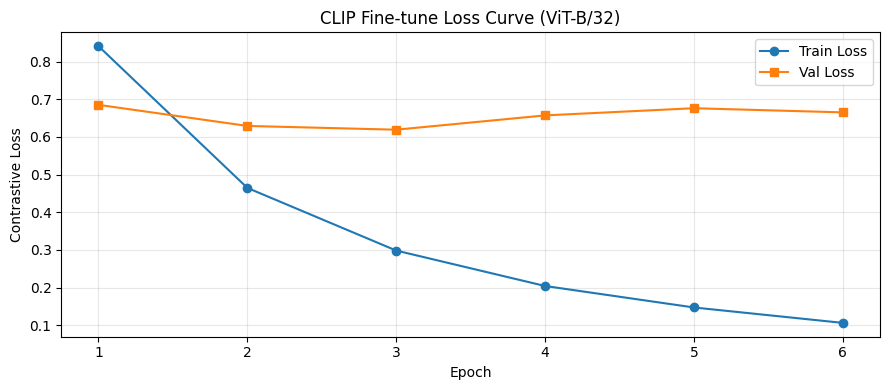

Loss curve saved: /kaggle/working/loss_curve.png


In [10]:
# Vẽ và lưu đường train/validation loss theo epoch.
# Chỉ vẽ khi đã có đủ lịch sử loss.
if train_losses and val_losses:
    epochs_range = range(1, len(train_losses) + 1)

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(epochs_range, train_losses, marker='o', label='Train Loss')

    ax.plot(epochs_range, val_losses, marker='s', label='Val Loss')

    ax.set_xlabel('Epoch')

    ax.set_ylabel('Contrastive Loss')

    ax.set_title(f'CLIP Fine-tune Loss Curve ({CLIP_MODEL})')

    ax.legend()

    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    loss_curve_path = Path('/kaggle/working') / 'loss_curve.png'

    plt.savefig(loss_curve_path, dpi=120)

    plt.show()

    print(f'Loss curve saved: {loss_curve_path}')
else:
    print('Chưa có lịch sử loss để vẽ.')

In [ ]:
# Dinh nghia ham ho tro: thu embedding va tinh retrieval metrics.
# Cac ham nay duoc dung o ca cell baseline va cell ket qua.

@torch.no_grad()
def collect_embeddings(model, loader, max_samples=None):
    #Thu embedding anh, van ban va caption_id; ket qua duoc chuan hoa tren CPU.
    model.eval()
    image_features = []
    text_features  = []
    all_caption_ids = []
    collected = 0

    for images, texts, caption_ids in loader:
        if max_samples is not None and collected >= max_samples:
            break
        if max_samples is not None:
            remaining = max_samples - collected
            images      = images[:remaining]
            texts       = texts[:remaining]
            caption_ids = caption_ids[:remaining]

        images = images.to(DEVICE, non_blocking=(DEVICE == 'cuda'))
        texts  = texts.to(DEVICE,  non_blocking=(DEVICE == 'cuda'))

        with autocast_context():
            img_feat = model.encode_image(images)
            txt_feat = model.encode_text(texts)

        img_feat = F.normalize(img_feat.float(), dim=-1).cpu()
        txt_feat = F.normalize(txt_feat.float(), dim=-1).cpu()

        image_features.append(img_feat)
        text_features.append(txt_feat)
        all_caption_ids.append(caption_ids.cpu())
        collected += images.size(0)

    assert collected > 0, 'Khong thu duoc embedding tu loader'
    return (
        torch.cat(image_features),
        torch.cat(text_features),
        torch.cat(all_caption_ids),
    )


@torch.no_grad()
def retrieval_metrics_chunked(
    query_features,
    target_features,
    query_ids,
    target_ids,
    ks=(1, 5, 10),
    chunk_size=256,
):
    """Tinh Recall@K, Precision@K va MRR theo tung chunk de tiet kiem VRAM."""
    max_k = min(max(ks), len(target_features))
    target_features_device = target_features.to(DEVICE)
    target_ids_device      = target_ids.to(DEVICE)

    hits      = {k: 0 for k in ks}
    precision = {k: 0.0 for k in ks}
    reciprocal_rank_sum = 0.0
    total_queries = len(query_features)

    for start in range(0, total_queries, chunk_size):
        end    = min(start + chunk_size, total_queries)
        q_feat = query_features[start:end].to(DEVICE)
        q_ids  = query_ids[start:end].to(DEVICE)

        similarities   = q_feat @ target_features_device.T
        ranked_indices = similarities.topk(max_k, dim=1).indices
        ranked_ids     = target_ids_device[ranked_indices]
        matches        = ranked_ids.eq(q_ids[:, None])

        for k in ks:
            eff_k = min(k, max_k)
            hits[k]      += matches[:, :eff_k].any(dim=1).sum().item()
            precision[k] += (matches[:, :eff_k].float().sum(dim=1) / eff_k).sum().item()

        positive_mask        = q_ids[:, None].eq(target_ids_device[None, :])
        best_positive_score  = similarities.masked_fill(~positive_mask, -torch.inf).max(dim=1).values
        ranks                = 1 + (similarities > best_positive_score[:, None]).sum(dim=1)
        reciprocal_rank_sum += (1.0 / ranks.float()).sum().item()

        del similarities, ranked_indices, ranked_ids, matches, positive_mask

    metrics = {}
    for k in ks:
        metrics['Recall@{}'.format(k)]    = hits[k]      / total_queries
        metrics['Precision@{}'.format(k)] = precision[k] / total_queries
    metrics['MRR'] = reciprocal_rank_sum / total_queries
    return metrics


print('Dinh nghia collect_embeddings va retrieval_metrics_chunked OK')
print('  Metrics duoc tinh: Recall@K, Precision@K, MRR')

Dinh nghia collect_embeddings va retrieval_metrics_chunked OK
  Metrics duoc tinh: Recall@K, Precision@K, MRR


In [12]:
# BASELINE: Load best model, so sanh CLIP Pretrained vs Fine-tuned

# Buoc 0: Load fashion_clip_best.pt vao clip_model truoc khi chay metrics
best_ckpt_path = CHECKPOINT_DIR / 'fashion_clip_best.pt'
assert best_ckpt_path.exists(), 'Khong tim thay fashion_clip_best.pt'

best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
clip_model.load_state_dict(best_ckpt['model_state_dict'])
clip_model.eval()

# Doc lai best_epoch tu checkpoint neu chua co
if best_epoch is None:
    best_epoch = best_ckpt.get('epoch', '?')

print('Da load fashion_clip_best.pt (epoch {}, val_loss={:.4f})'.format(
    best_ckpt.get('epoch', '?'), best_ckpt.get('val_loss', float('nan'))
))

# Buoc 1: Thu embedding voi CLIP pretrained (frozen)
print('\n[1/2] Thu embedding CLIP pretrained (frozen)...')
pretrained_model, _ = clip.load(CLIP_MODEL, device=DEVICE, jit=False)
pretrained_model = pretrained_model.float().eval()

pre_img_feat, pre_txt_feat, pre_cap_ids = collect_embeddings(
    pretrained_model, test_loader, max_samples=RETRIEVAL_MAX_SAMPLES,
)
pre_i2t = retrieval_metrics_chunked(
    pre_img_feat, pre_txt_feat, pre_cap_ids, pre_cap_ids,
    chunk_size=RETRIEVAL_CHUNK_SIZE,
)
pre_t2i = retrieval_metrics_chunked(
    pre_txt_feat, pre_img_feat, pre_cap_ids, pre_cap_ids,
    chunk_size=RETRIEVAL_CHUNK_SIZE,
)
del pretrained_model
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

# Buoc 2: Thu embedding voi CLIP fine-tuned (best checkpoint)
print('[2/2] Thu embedding CLIP fine-tuned (best checkpoint)...')
ft_img_feat, ft_txt_feat, ft_cap_ids = collect_embeddings(
    clip_model, test_loader, max_samples=RETRIEVAL_MAX_SAMPLES,
)
ft_i2t = retrieval_metrics_chunked(
    ft_img_feat, ft_txt_feat, ft_cap_ids, ft_cap_ids,
    chunk_size=RETRIEVAL_CHUNK_SIZE,
)
ft_t2i = retrieval_metrics_chunked(
    ft_txt_feat, ft_img_feat, ft_cap_ids, ft_cap_ids,
    chunk_size=RETRIEVAL_CHUNK_SIZE,
)

# Buoc 3: In bang so sanh
METRICS_SHOW = ['Recall@1', 'Precision@5', 'Recall@5', 'Recall@10', 'MRR']
col_h = '{:<22} {:>12} {:>12} {:>10}'.format('Metric', 'Pretrained', 'Fine-tuned', 'Delta')
sep   = '-' * len(col_h)

print('\nSo mau danh gia: {:,}'.format(len(ft_cap_ids)))
print('\n' + sep)
print('  CLIP Pretrained vs Fine-tuned | epoch {} | n={:,}'.format(best_epoch, len(ft_cap_ids)))
print(sep)
print(col_h)
print(sep)
print('Image => Text')
for k in METRICS_SHOW:
    if k not in pre_i2t:
        continue
    pre  = pre_i2t[k]
    ft   = ft_i2t[k]
    mark = '(+)' if ft > pre else ('(-)' if ft < pre else '(=)')
    print('  {:<20} {:>12.4f} {:>12.4f} {:>+9.4f} {}'.format(k, pre, ft, ft - pre, mark))
print(sep)
print('Text => Image')
for k in METRICS_SHOW:
    if k not in pre_t2i:
        continue
    pre  = pre_t2i[k]
    ft   = ft_t2i[k]
    mark = '(+)' if ft > pre else ('(-)' if ft < pre else '(=)')
    print('  {:<20} {:>12.4f} {:>12.4f} {:>+9.4f} {}'.format(k, pre, ft, ft - pre, mark))
print(sep)

# Gan bien cho cac cell phia sau dung lai
test_image_features = ft_img_feat
test_text_features  = ft_txt_feat
test_caption_ids    = ft_cap_ids
image_to_text       = ft_i2t
text_to_image       = ft_t2i

# Luu ket qua ra JSON
import json as _json
comparison = {
    'n_samples':  int(len(ft_cap_ids)),
    'best_epoch': best_epoch,
    'pretrained': {'i2t': pre_i2t, 't2i': pre_t2i},
    'finetuned':  {'i2t': ft_i2t,  't2i': ft_t2i},
}
with open('/kaggle/working/baseline_comparison.json', 'w') as _f:
    _json.dump(comparison, _f, indent=2)
print('\nDa luu: /kaggle/working/baseline_comparison.json')


Da load fashion_clip_best.pt (epoch 3, val_loss=0.6191)

[1/2] Thu embedding CLIP pretrained (frozen)...
[2/2] Thu embedding CLIP fine-tuned (best checkpoint)...

So mau danh gia: 5,000

-----------------------------------------------------------
  CLIP Pretrained vs Fine-tuned | epoch 3 | n=5,000
-----------------------------------------------------------
Metric                   Pretrained   Fine-tuned      Delta
-----------------------------------------------------------
Image => Text
  Recall@1                   0.0594       0.2358   +0.1764 (+)
  Precision@5                0.0329       0.1109   +0.0780 (+)
  Recall@5                   0.1632       0.4820   +0.3188 (+)
  Recall@10                  0.2402       0.6036   +0.3634 (+)
  MRR                        0.1202       0.3551   +0.2349 (+)
-----------------------------------------------------------
Text => Image
  Recall@1                   0.0604       0.2572   +0.1968 (+)
  Precision@5                0.0356       0.1217   +0.0

Chay t-SNE tren 2,000 diem (5 category)...
Categories: ['dresses', 'jackets', 'pants', 'skirts', 'tops']
  Dang chay t-SNE cho image features...
  Dang chay t-SNE cho text features...
t-SNE hoan thanh.


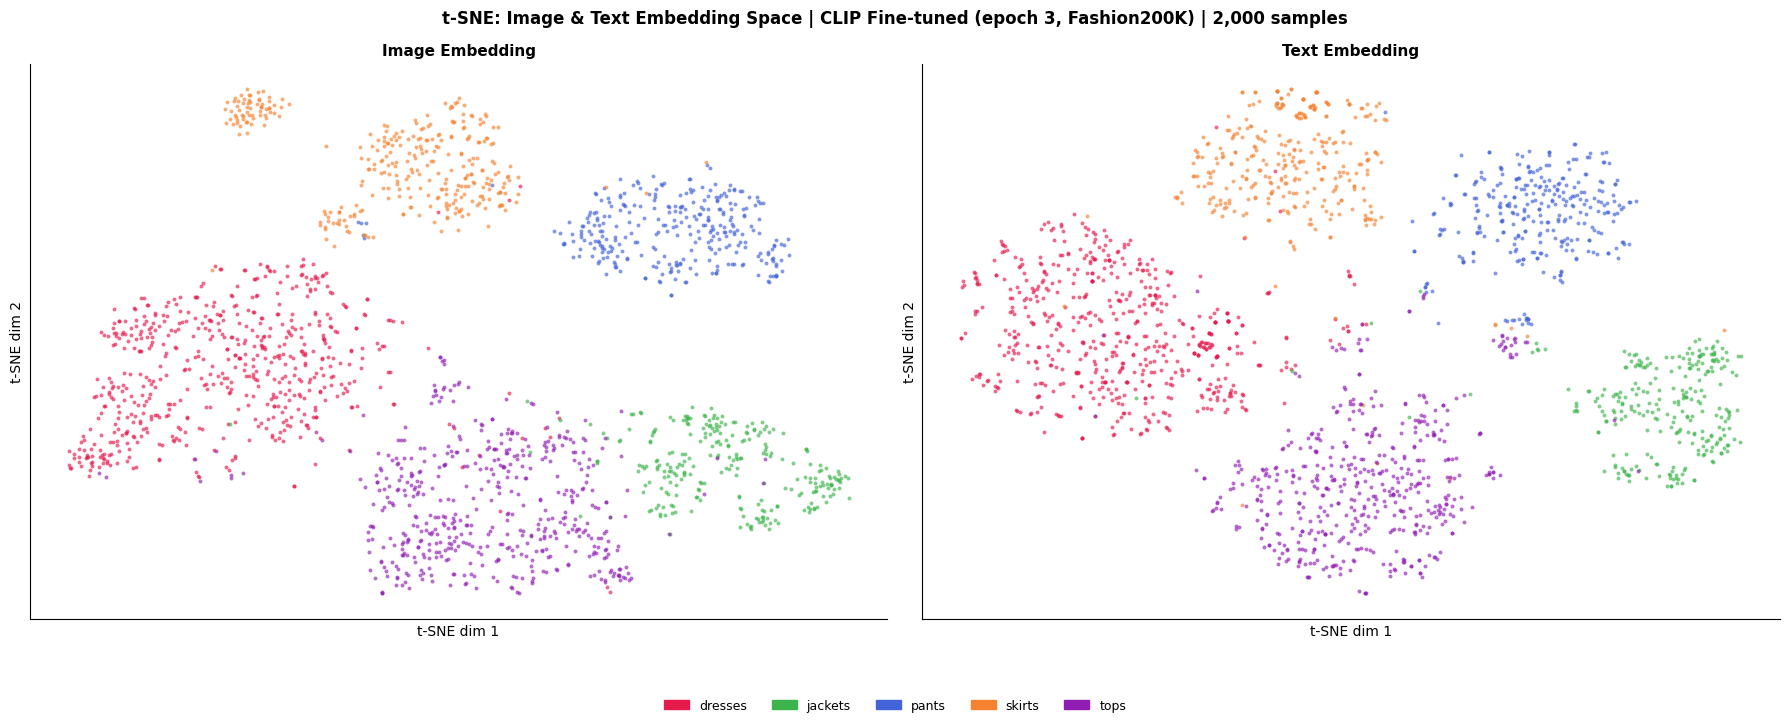

Da luu: /kaggle/working/tsne_visualization.png


In [13]:
# t-SNE Visualization: Embedding space sau fine-tuning
# Muc dich: cho thay embedding cung category tu lai thanh cum ro rang
# sau khi fine-tune CLIP tren Fashion200K.

from sklearn.manifold import TSNE

TSNE_N_SAMPLES = 2000
TSNE_PERPLEXITY = 40
TSNE_MAX_ITER = 1000
TSNE_SEED = SEED

# 1. Lay features + category labels
# ft_img_feat va ft_txt_feat da duoc tinh o cell baseline phia tren.
n_vis = min(TSNE_N_SAMPLES, len(ft_img_feat))
vis_img  = ft_img_feat[:n_vis].numpy()
vis_txt  = ft_txt_feat[:n_vis].numpy()

vis_categories = df_test['category'].iloc[:n_vis].tolist()
unique_cats = sorted(set(vis_categories))
cat2idx = {c: i for i, c in enumerate(unique_cats)}

print("Chay t-SNE tren {:,} diem ({} category)...".format(n_vis, len(unique_cats)))
print("Categories:", unique_cats)

# 2. Giam chieu xuong 2D bang t-SNE
def run_tsne(features, seed=TSNE_SEED):
    return TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        max_iter=TSNE_MAX_ITER,
        random_state=seed,
        init='pca',
        learning_rate='auto',
        verbose=0,
    ).fit_transform(features)

print("  Dang chay t-SNE cho image features...")
img_2d = run_tsne(vis_img)
print("  Dang chay t-SNE cho text features...")
txt_2d = run_tsne(vis_txt)
print("t-SNE hoan thanh.")

# 3. Ve scatter plot (Image | Text) cung palette
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PALETTE = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#469990','#9A6324',
]
while len(PALETTE) < len(unique_cats):
    PALETTE += PALETTE

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

title_main = (
    "t-SNE: Image & Text Embedding Space"
    " | CLIP Fine-tuned (epoch {}, Fashion200K)"
    " | {:,} samples".format(best_epoch, n_vis)
)
fig.suptitle(title_main, fontsize=12, fontweight='bold')

for ax, coords, title in zip(
    axes,
    [img_2d, txt_2d],
    ["Image Embedding", "Text Embedding"],
):
    for cat, cidx in cat2idx.items():
        mask = [i for i, c in enumerate(vis_categories) if c == cat]
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=PALETTE[cidx], label=cat,
            s=8, alpha=0.65, linewidths=0,
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [
    mpatches.Patch(color=PALETTE[cat2idx[c]], label=c)
    for c in unique_cats
]
fig.legend(
    handles=handles,
    loc='lower center',
    ncol=min(len(unique_cats), 5),
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

tsne_path = '/kaggle/working/tsne_visualization.png'
plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
plt.show()
print("Da luu: " + tsne_path)

In [14]:
# Kiểm tra checkpoint tốt nhất bằng cách load lại và chạy inference trên CPU.
# Liệt kê các checkpoint đã lưu.
print('Checkpoint files:')

for file_path in sorted(CHECKPOINT_DIR.glob('*.pt')):
    size_mb = file_path.stat().st_size / 1e6
    print(f'  {file_path.name:40s} {size_mb:.1f} MB')

best_pt = CHECKPOINT_DIR / 'fashion_clip_best.pt'

assert best_pt.exists(), 'Không tìm thấy fashion_clip_best.pt'
print('\n fashion_clip_best.pt tồn tại')

print('\nTest load và inference từ best checkpoint...')

# Load về CPU để kiểm tra checkpoint có thể dùng độc lập với GPU.
best_payload = torch.load(best_pt, map_location='cpu')

# Hỗ trợ cả checkpoint có metadata và state_dict cũ.
if isinstance(best_payload, dict) and 'model_state_dict' in best_payload:
    saved_model_name = best_payload.get('model_name', CLIP_MODEL)

    best_state_dict = best_payload['model_state_dict']

    print(f'  Saved epoch         : {best_payload.get("epoch", "unknown")}')
    print(f'  Saved val loss      : {best_payload.get("val_loss", float("nan")):.4f}')
else:
    saved_model_name = CLIP_MODEL
    best_state_dict = best_payload
    print(' Best model dùng định dạng state_dict cũ')

# Tạo lại đúng kiến trúc CLIP rồi nạp trọng số đã lưu.
test_model, test_preprocess = clip.load(saved_model_name, device='cpu', jit=False)

test_model = test_model.float()

test_model.load_state_dict(best_state_dict)

test_model.eval()

sample_path = Path(df_test.iloc[0]['image_path'])

# Chạy sanity check trên một ảnh test.
if sample_path.exists():
    t0 = time.time()

    with torch.no_grad(), Image.open(sample_path) as sample_image:
        img_input = test_preprocess(sample_image.convert('RGB')).unsqueeze(0)

        feat = test_model.encode_image(img_input)

        feat = F.normalize(feat.float(), dim=-1)

    elapsed_ms = (time.time() - t0) * 1000

    print(f'  Image feature shape : {feat.shape}')

    print(f'  Feature norm        : {feat.norm(dim=-1).item():.4f}')

    print(f'  Inference time      : {elapsed_ms:.0f} ms')
else:
    print(f' Không tìm thấy ảnh mẫu: {sample_path}')

print('   [x] Dữ liệu được kiểm tra và làm sạch')
print('   [x] Fine-tune CLIP với AMP an toàn')
print('   [x] Checkpoint resume đầy đủ')
print('   [x] Best model load được trên CPU')
print('   [x] Có sẵn retrieval metrics cho test set')

Checkpoint files:
  clip_epoch05.pt                          1815.7 MB
  clip_epoch06.pt                          1815.7 MB
  fashion_clip_best.pt                     605.2 MB

 fashion_clip_best.pt tồn tại

Test load và inference từ best checkpoint...
  Saved epoch         : 3
  Saved val loss      : 0.6191
  Image feature shape : torch.Size([1, 512])
  Feature norm        : 1.0000
  Inference time      : 188 ms
   [x] Dữ liệu được kiểm tra và làm sạch
   [x] Fine-tune CLIP với AMP an toàn
   [x] Checkpoint resume đầy đủ
   [x] Best model load được trên CPU
   [x] Có sẵn retrieval metrics cho test set
